In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("bank-full.csv",delimiter=";")

In [4]:
df_main=df.copy()


In [5]:
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [6]:
df.shape

(45211, 17)

In [7]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [8]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [9]:
for i in df.columns:
    if i in ["balance",'campaign','previous','day','duration','pdays','age']:
        continue
    print(df[i].value_counts())

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
default
no     44396
yes      815
Name: count, dtype: int64
housing
yes    25130
no     20081
Name: count, dtype: int64
loan
no     37967
yes     7244
Name: count, dtype: int64
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64
poutcome
unknown    36959
failure     4901
other  

In [10]:
bins=[18,30,45,60,np.inf]
label=["18_30","30_45","45_60","60+"]
df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=label,
    include_lowest=True
)

In [11]:
df['subscribed'] = (df['y'] == 'yes').astype(int)

<Axes: ylabel='job'>

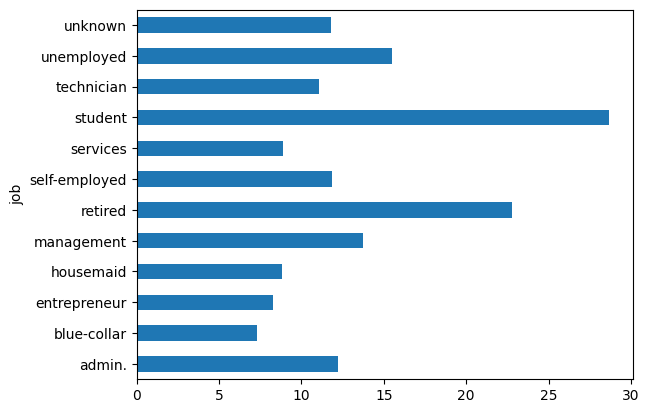

In [12]:
df.groupby('job')['subscribed'].mean().mul(100).round(2).plot(kind='barh')


### Which job types have the highest subscription rate?

Accoring to the figure shown above it shows subscription rate of the job the top 3 are :

C:\Users\nt458\AppData\Local\Temp\ipykernel_8224\3658616265.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['subscribed']


<Axes: ylabel='subscribed'>

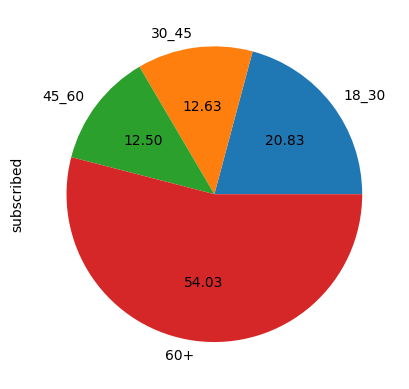

In [13]:
subscription_rate_age = (
    df.groupby('age_group')['subscribed']
      .mean()
      .mul(100)
      .round(2))
subscription_rate_age.plot(kind='pie',autopct='%.2f')

#### How does subscription rate differ across age groups? (bin into 18-30, 31-45, 46-60, 60+)
The subscription rate differ vary vastly across age categoroies the major insights are :-
#### More than 50% Senior citizen have subscribed to this
#### in the other age categories the youngester are subscribed the most as 20%

In [14]:
df[['housing','y']]

,housing,y
0,yes,no
1,yes,no
2,yes,no
3,yes,no
4,no,no
...,...,...
45206,no,yes
45207,no,yes
45208,no,yes
45209,no,no


In [15]:
df['housing']=(df['housing'] == 'yes').astype(int)

<Axes: ylabel='housing'>

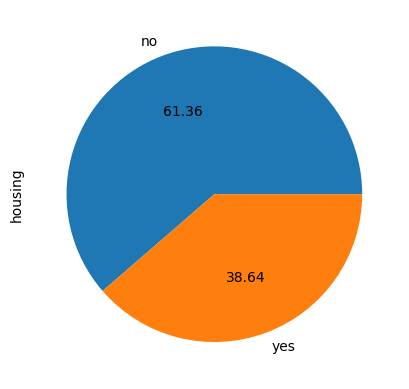

In [16]:
df.groupby('y')['housing'].mean().mul(100).round(2).plot(kind='pie',autopct='%.2f')


### Does having an existing housing loan make someone less likely to take a new product

#### Yes, it can be infer from the chart that there is more than 50 percent chance that people that are on  hosue loan will not take the new campain

In [17]:
df[['balance','subscribed']]

,balance,subscribed
0,2143,0
1,29,0
2,2,0
3,1506,0
4,1,0
...,...,...
45206,825,1
45207,1729,1
45208,5715,1
45209,668,0


In [18]:
df['balance_bin'] = pd.qcut(df['balance'], q=10)
df.groupby('balance_bin')['subscribed'].mean().mul(100).round(2)

C:\Users\nt458\AppData\Local\Temp\ipykernel_8224\1142145615.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('balance_bin')['subscribed'].mean().mul(100).round(2)


balance_bin
(-8019.001, 0.0]       6.90
(0.0, 22.0]            7.22
(22.0, 131.0]          9.18
(131.0, 272.0]        10.83
(272.0, 448.0]        11.41
(448.0, 701.0]        12.01
(701.0, 1126.0]       12.68
(1126.0, 1859.0]      14.25
(1859.0, 3574.0]      16.61
(3574.0, 102127.0]    16.12
Name: subscribed, dtype: float64

### Is there a pattern between account balance and likelihood to subscribe?
#### given the table above there is not much of a  pattern here

In [26]:
df.groupby()['subscribed'].mean().mul(100).round(2)

duration
0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
        ...  
3366      0.0
3422      0.0
3785      0.0
3881    100.0
4918      0.0
Name: subscribed, Length: 1573, dtype: float64